# Healthcare Disease Prediction - EDA & ETL

Comprehensive exploratory data analysis and data cleaning for disease prediction dataset

## 1. Import Libraries

### Overview
This section imports all the necessary Python libraries required for data analysis and manipulation:
- **pandas (pd)**: Used for data manipulation, reading CSV files, and creating DataFrames
- **numpy (np)**: Provides numerical computing capabilities for array operations
- **matplotlib.pyplot (plt)**: Used for creating static, interactive, and animated visualizations
- **seaborn (sns)**: Built on matplotlib, provides aesthetic data visualizations with statistical plots
- **warnings**: Suppresses warning messages to keep output clean

We also configure the plotting style and figure size globally to ensure consistent visualization appearance throughout the notebook.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load & Explore Data

### Overview
This section loads the healthcare dataset from a CSV file and performs initial exploratory analysis:
- **df.read_csv()**: Reads the CSV file into a pandas DataFrame
- **df.shape**: Displays the number of rows and columns (dimensions) of the dataset
- **df.head()**: Shows the first 5 rows to get a quick preview of the data
- **df.dtypes**: Identifies the data type of each column (integer, float, object/string, etc.)
- **df.describe()**: Generates comprehensive statistical summary including count, mean, std, min, max, and quartiles for numerical columns

This exploratory phase helps us understand the dataset structure and identify any immediate data quality issues.

In [6]:
# Load dataset
df = pd.read_csv('healthcare_disease_prediction_dataset.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst Few Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (1000, 20)

First Few Rows:
   Age  Gender Blood Pressure Cholesterol Glucose Smoking Alcohol Consumption  \
0   69    Male           High        High    High     Yes                  No   
1   32    Male            Low        High  Normal     Yes                  No   
2   89  Female         Normal        High  Normal      No                  No   
3   78    Male           High        High    High      No                  No   
4   38    Male            Low      Normal  Normal     Yes                 Yes   

  Exercise        BMI Family History  Heart Disease  Diabetes  Stroke  \
0       No  35.671099             No              1         0       0   
1      Yes  38.554188            Yes              0         1       0   
2      Yes  18.932964            Yes              1         0       0   
3      Yes  21.806350            Yes              0         1       1   
4      Yes  37.552683             No              0         0       0   

   Kidney Disease  Cancer  Alzh

## 3. Data Quality Check

### Overview
This section performs comprehensive data quality validation checks to identify potential data issues:
- **df.isnull().sum()**: Counts missing (null) values in each column - essential for determining data completeness
- **df.duplicated().sum()**: Identifies duplicate rows that may skew analysis or model performance
- **Dataset dimensions and memory usage**: Provides information about the dataset size and memory footprint
- **Column-level information loop**: Iterates through each column to display its data type, number of unique values, and count of non-null entries

These checks help identify data quality issues that need to be addressed during the cleaning phase, such as missing values, duplicates, or data type mismatches.

In [7]:
# Check missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

# Check duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Check for inconsistencies
print("\nData Quality Summary:")
print(f"Total Rows: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display column-wise info
print("\nColumn Information:")
for col in df.columns:
    print(f"{col}: {df[col].dtype} | Unique: {df[col].nunique()} | Non-null: {df[col].notna().sum()}")

Missing Values:
No missing values found!

Duplicate Rows: 0

Data Quality Summary:
Total Rows: 1000
Total Columns: 20
Memory Usage: 0.49 MB

Column Information:
Age: int64 | Unique: 72 | Non-null: 1000
Gender: str | Unique: 2 | Non-null: 1000
Blood Pressure: str | Unique: 3 | Non-null: 1000
Cholesterol: str | Unique: 2 | Non-null: 1000
Glucose: str | Unique: 2 | Non-null: 1000
Smoking: str | Unique: 2 | Non-null: 1000
Alcohol Consumption: str | Unique: 2 | Non-null: 1000
Exercise: str | Unique: 2 | Non-null: 1000
BMI: float64 | Unique: 1000 | Non-null: 1000
Family History: str | Unique: 2 | Non-null: 1000
Heart Disease: int64 | Unique: 2 | Non-null: 1000
Diabetes: int64 | Unique: 2 | Non-null: 1000
Stroke: int64 | Unique: 2 | Non-null: 1000
Kidney Disease: int64 | Unique: 2 | Non-null: 1000
Cancer: int64 | Unique: 2 | Non-null: 1000
Alzheimer's Disease: int64 | Unique: 2 | Non-null: 1000
COPD: int64 | Unique: 2 | Non-null: 1000
Liver Disease: int64 | Unique: 2 | Non-null: 1000
Parkinso

## 4. Categorical Variables Analysis

### Overview
This section analyzes categorical (text/string) variables to understand their distributions and characteristics:
- **df.select_dtypes(include=['object'])**: Filters only columns with object/string data types
- **df[col].value_counts()**: Shows frequency distribution of each unique category value
- **Bar plots**: Creates visual representations of categorical distributions, making patterns easier to identify

Categorical variables like Gender, Blood Pressure, and Smoking status are crucial for disease prediction. Analyzing their distributions helps identify:
  - Class imbalance (if some categories are over/underrepresented)
  - Missing or unexpected values
  - Distribution patterns that may correlate with disease outcomes

Categorical Columns: ['Gender', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking', 'Alcohol Consumption', 'Exercise', 'Family History']

Gender:
Gender
Male      503
Female    497
Name: count, dtype: int64
Missing: 0

Blood Pressure:
Blood Pressure
Normal    352
High      344
Low       304
Name: count, dtype: int64
Missing: 0

Cholesterol:
Cholesterol
Normal    514
High      486
Name: count, dtype: int64
Missing: 0

Glucose:
Glucose
Normal    510
High      490
Name: count, dtype: int64
Missing: 0

Smoking:
Smoking
Yes    502
No     498
Name: count, dtype: int64
Missing: 0

Alcohol Consumption:
Alcohol Consumption
No     505
Yes    495
Name: count, dtype: int64
Missing: 0

Exercise:
Exercise
Yes    505
No     495
Name: count, dtype: int64
Missing: 0

Family History:
Family History
Yes    503
No     497
Name: count, dtype: int64
Missing: 0


IndexError: index 2 is out of bounds for axis 0 with size 2

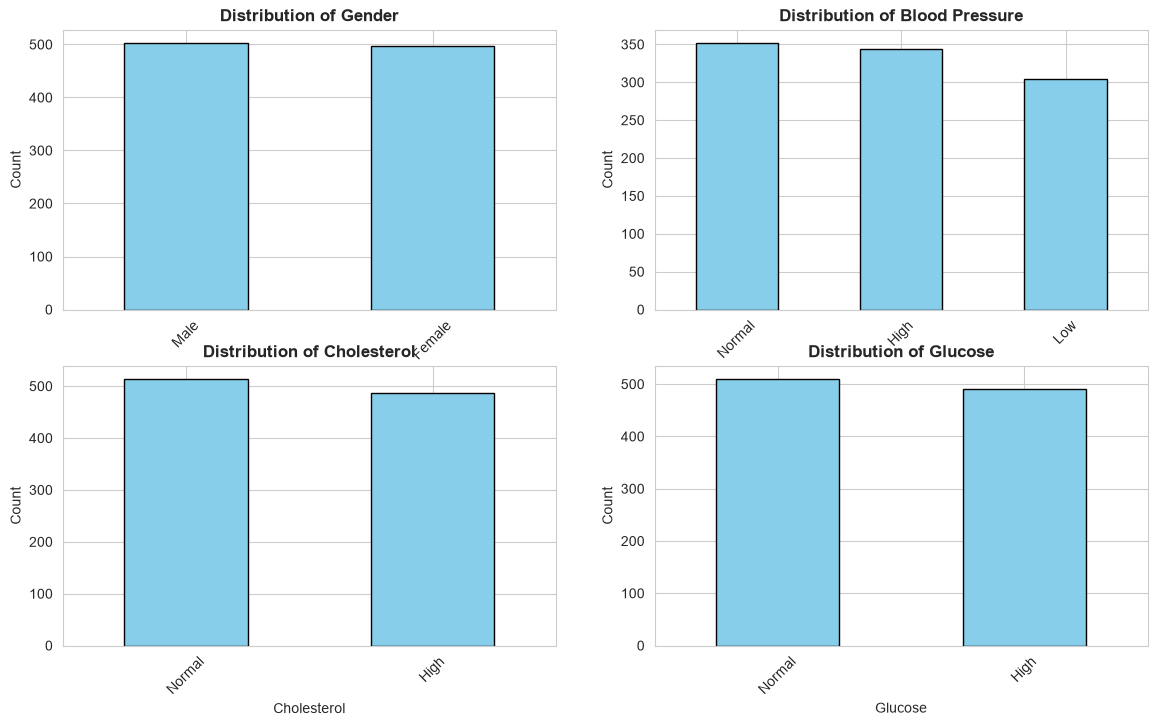

In [8]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Columns: {categorical_cols}")

# Value counts for categorical variables
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Missing: {df[col].isnull().sum()}")

# Visualize categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for idx, col in enumerate(categorical_cols):
    ax = axes[idx // 2, idx % 2]
    df[col].value_counts().plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

if len(categorical_cols) < 4:
    fig.delaxes(axes[1, 1] if len(categorical_cols) == 3 else axes[1, 0])

plt.tight_layout()
plt.show()

## 5. Numerical Variables Analysis

### Overview
This section analyzes numerical (quantitative) variables to understand their ranges, distributions, and outliers:
- **Numerical column identification**: Filters columns containing numeric data types (int64, float64)
- **Statistical summary (.describe())**: Displays mean, standard deviation, minimum, maximum, and quartile values
- **Outlier detection using IQR method**: 
  - Calculates Interquartile Range (IQR = Q3 - Q1)
  - Identifies outliers as values beyond 1.5 × IQR from quartile boundaries
  - Outliers can indicate data entry errors or genuinely extreme cases
- **Histograms**: Visualize the distribution patterns of numerical features to identify skewness or multimodality

Understanding numerical distributions is critical for preprocessing steps like normalization and for identifying variables that may need transformation before modeling.

In [ ]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical Columns: {numerical_cols}")

# Statistical summary
print("\nStatistical Summary:")
print(df[numerical_cols].describe().T)

# Check for outliers using IQR method
print("\nOutlier Detection (IQR Method):")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower_bound:.2f} - {upper_bound:.2f})")

# Visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols[:6]):
    axes[idx].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

### Overview
This section analyzes relationships between numerical variables and identifies which features most strongly correlate with disease outcomes:
- **Correlation matrix**: Calculates Pearson correlation coefficients between all numerical variables
  - Ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation)
  - 0 indicates no linear relationship
- **Heatmap visualization**: Color-coded matrix where warm colors (red) indicate strong positive correlations and cool colors (blue) indicate negative correlations
- **Feature importance ranking**: Identifies which factors are most strongly associated with each disease, helping prioritize features for predictive modeling

High correlations with disease targets indicate strong predictive potential, while correlations between features help identify multicollinearity that may need to be addressed during preprocessing.

In [ ]:
# Correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target variables (disease columns)
target_cols = [col for col in df.columns if col not in numerical_cols + categorical_cols]
print(f"\nTarget Variables: {target_cols[:5]}...")  # Show first 5
print("\nTop Correlations with Heart Disease:")
hd_corr = correlation_matrix['Heart Disease'].sort_values(ascending=False)
print(hd_corr[hd_corr.index != 'Heart Disease'].head())

## 7. Data Cleaning (ETL)

### Overview
This section performs essential data cleaning operations to prepare the dataset for analysis and modeling:
- **df.copy()**: Creates a working copy to preserve the original dataset for reference
- **df.dropna()**: Removes rows containing any missing values (NaN/null values)
  - This ensures complete records for analysis
  - Can lead to data loss if many rows have missing values
- **df.drop_duplicates()**: Removes identical rows that may bias statistical analyses or model training
  - Duplicates can result from data entry errors or system glitches
- **Text standardization**: Converts categorical text to lowercase and removes leading/trailing whitespace
  - Ensures consistent formatting for proper encoding and comparison
  - Prevents "Male" and "male" from being treated as different categories

Data cleaning is critical because machine learning algorithms perform poorly on dirty, inconsistent data. Clean data leads to more reliable models and analyses.

In [ ]:
# Create a copy for ETL operations
df_clean = df.copy()

# Handle missing values (if any)
print("Handling Missing Values...")
df_clean = df_clean.dropna()
print(f"Rows after removing missing values: {len(df_clean)}")

# Remove duplicates
print(f"\nRemoving Duplicates...")
print(f"Duplicates before: {df_clean.duplicated().sum()}")
df_clean = df_clean.drop_duplicates()
print(f"Duplicates after: {df_clean.duplicated().sum()}")
print(f"Rows after removing duplicates: {len(df_clean)}")

# Standardize text data (lowercase)
print("\nStandardizing Text Data...")
for col in categorical_cols:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].str.lower().str.strip()
        print(f"  {col}: standardized")

print("\nData Cleaning Completed!")
print(f"Final Dataset Shape: {df_clean.shape}")

## 8. Feature Encoding & Transformation

### Overview
This section converts categorical text variables into numerical format, which is required for machine learning algorithms:
- **Encoding strategy**: Maps each categorical value to a numeric code
  - Binary variables (Yes/No): encoded as 0/1
  - Ordinal variables (Blood Pressure levels): encoded as 0 (Low) → 1 (Normal) → 2 (High) to preserve order
  - Binary gender: Male=0, Female=1
- **Mapping dictionary**: Defines consistent transformations for all categorical features
- **df.map()**: Applies the encoding transformations to each column

Why encoding is necessary:
  - Machine learning algorithms work with numerical data, not text
  - Ordinal encoding preserves relationships (High > Normal > Low)
  - Consistent encoding ensures reproducibility across datasets
  
After encoding, all features are numerical and ready for scaling and modeling.

In [ ]:
# Encoding Categorical Variables
df_encoded = df_clean.copy()

# Define encoding mappings
encoding_mappings = {
    'Gender': {'male': 0, 'female': 1},
    'Blood Pressure': {'low': 0, 'normal': 1, 'high': 2},
    'Cholesterol': {'low': 0, 'normal': 1, 'high': 2},
    'Glucose': {'low': 0, 'normal': 1, 'high': 2},
    'Smoking': {'no': 0, 'yes': 1},
    'Alcohol Consumption': {'no': 0, 'yes': 1},
    'Exercise': {'no': 0, 'yes': 1},
    'Family History': {'no': 0, 'yes': 1}
}

print("Encoding Categorical Variables...")
for col, mapping in encoding_mappings.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping)
        print(f"  {col}: encoded using mapping")

print("\nEncoding Completed!")
print(f"\nDataset after encoding:")
print(df_encoded.head())
print(f"\nData Types After Encoding:")
print(df_encoded.dtypes)

## 9. Feature Scaling & Normalization

### Overview
This section standardizes numerical features to have consistent scales, which improves machine learning model performance:
- **StandardScaler (Z-score normalization)**: Transforms features to have mean=0 and standard deviation=1
  - Formula: (value - mean) / standard_deviation
  - Useful for algorithms sensitive to feature magnitude (SVM, KNN, Neural Networks)
  - Preserves the distribution shape while centering and scaling
- **Features selected for scaling**: Age and BMI (continuous numerical variables)
  - Categorical features already in 0-1 range, so no scaling needed
- **scaler.fit_transform()**: Calculates statistics from training data and applies transformation

Why scaling matters:
  - Algorithms like SVM, KNN, and gradient descent-based models are sensitive to feature scales
  - Unscaled features can dominate others just because they have larger ranges (e.g., Age in years vs. BMI)
  - Scaled features improve model convergence and accuracy
  - Comparison before/after shows the transformation effect clearly

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify features to scale (numerical features)
features_to_scale = ['Age', 'BMI']

# Create a copy for scaling
df_scaled = df_encoded.copy()

# Standardization (Z-score normalization)
scaler = StandardScaler()
df_scaled[features_to_scale] = scaler.fit_transform(df_encoded[features_to_scale])

print("Feature Scaling Applied:")
print(f"Scaled features: {features_to_scale}")
print(f"\nBefore Scaling (Sample):")
print(df_encoded[features_to_scale].head())
print(f"\nAfter Scaling (Sample):")
print(df_scaled[features_to_scale].head())

print(f"\nScaled Data Statistics:")
print(df_scaled[features_to_scale].describe())

## 10. Final Dataset Summary & Export

### Overview
This final section summarizes the complete data processing pipeline and exports the clean, processed dataset:
- **Data transformation summary**: Compares original vs. cleaned vs. final processed datasets
  - Tracks how many rows were removed due to missing values or duplicates
  - Shows dimension changes through each processing step
- **Data validation**: Confirms all features are numerical and ready for modeling
  - Verifies encoding was successful
  - Confirms scaling was applied
- **Feature categorization**: Distinguishes between numerical (scaled) and categorical (encoded) features
- **CSV export**: Saves the processed dataset for use in machine learning pipelines
  - `index=False` prevents row indices from being written to file
  - Clean dataset serves as input for model training and evaluation

This creates a clean, standardized dataset that is:
  ✓ Free of missing values and duplicates
  ✓ Properly encoded (categorical → numerical)
  ✓ Properly scaled (features on comparable ranges)
  ✓ Ready for machine learning algorithms

In [ ]:
print("=" * 60)
print("DATA PROCESSING SUMMARY")
print("=" * 60)

print(f"\nOriginal Dataset:")
print(f"  Shape: {df.shape}")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print(f"  Duplicates: {df.duplicated().sum()}")

print(f"\nCleaned Dataset:")
print(f"  Shape: {df_clean.shape}")
print(f"  Rows Removed: {df.shape[0] - df_clean.shape[0]}")

print(f"\nFinal Processed Dataset (Encoded & Scaled):")
print(f"  Shape: {df_scaled.shape}")
print(f"  All Numeric: {df_scaled.dtypes.apply(lambda x: str(x).startswith('int') or str(x).startswith('float')).all()}")

print(f"\nColumn Information:")
print(f"  Total Features: {len(df_scaled.columns)}")
print(f"  Numerical Features: {len(features_to_scale)}")
print(f"  Categorical Features (Encoded): {len(df_scaled.columns) - len(features_to_scale)}")

# Export cleaned data
print("\nExporting Processed Data...")
df_scaled.to_csv('healthcare_dataset_cleaned.csv', index=False)
print("✓ Saved: healthcare_dataset_cleaned.csv")

# Summary statistics
print("\nFinal Dataset Statistics:")
print(df_scaled.describe())

print("\n" + "=" * 60)
print("✓ EDA and ETL Process Completed Successfully!")
print("=" * 60)

---

# Machine Learning Models for Disease Prediction

This section implements and compares various machine learning algorithms for disease prediction

## 11. Data Preparation for Model Training

### Overview
This section prepares the processed data for machine learning model training:
- **Features (X) and Target (y) separation**: 
  - X contains all independent variables (predictors) like Age, BMI, Blood Pressure, etc.
  - y contains the target variable (disease outcome) we want to predict
- **Train-test split (80-20)**:
  - 80% of data used for training models to learn patterns
  - 20% held out for testing to evaluate generalization performance
  - random_state=42 ensures reproducibility across runs
  - stratify maintains class distribution in both train and test sets (important for imbalanced data)
- **Model evaluation metrics**:
  - Accuracy: Percentage of correct predictions
  - Precision: Of positive predictions, how many were correct
  - Recall: Of actual positives, how many did model catch
  - F1-Score: Harmonic mean of precision and recall (balanced metric)
  - ROC-AUC: Area under receiver operating characteristic curve (0.5=random, 1.0=perfect)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import pandas as pd

# Separate features and target (using one disease as example: Heart Disease)
X = df_scaled.drop(columns=['Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 
                             'Cancer', 'Alzheimer\'s Disease', 'COPD', 'Liver Disease', 
                             'Parkinson\'s Disease', 'Tuberculosis'])
y = df_scaled['Heart Disease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

# Function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    """Evaluate and print model performance metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"{'='*50}")
    
    return {'Model': model_name, 'Accuracy': accuracy, 'Precision': precision, 
            'Recall': recall, 'F1-Score': f1}

# Store results
results = []

## 12. Logistic Regression

### Detailed Explanation
**Logistic Regression** is a linear classification algorithm that models the probability of a binary outcome:

**How it works:**
- Uses the **sigmoid function**: probability = 1 / (1 + e^(-z)) to map linear combinations to probabilities [0,1]
- Learns coefficients (weights) for each feature that maximize likelihood of correct predictions
- Decision boundary: predicts class 1 if probability > 0.5, otherwise class 0
- Outputs probability scores, not just binary predictions

**Key characteristics:**
- **Interpretability**: Coefficients directly show feature impact direction and magnitude
- **Efficiency**: Fast to train and predict, works well with linearly separable data
- **Probabilistic**: Provides probability estimates useful for ranking predictions
- **Sensitivity**: Affected by feature scaling (our scaled data is ideal)
- **Regularization**: L1 (Lasso) and L2 (Ridge) options prevent overfitting

**When to use:**
- Binary classification problems with relatively balanced classes
- When model interpretability is important
- Quick baseline model for comparison
- When computational efficiency matters

**Parameters:**
- max_iter: Number of iterations for optimization (increased to 1000 for convergence)
- random_state: Seed for reproducibility

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate
lr_results = evaluate_model(y_test, y_pred_lr, "Logistic Regression")
results.append(lr_results)

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Most Important Features (by coefficient magnitude):")
print(feature_importance.head(10))

## 13. Decision Tree Classifier (Entropy & Information Gain)

### Detailed Explanation
**Decision Tree** is a hierarchical model that makes predictions through a series of binary questions about features:

**How it works:**
- **Recursively splits** data into subsets based on feature values
- Each node asks: "If feature X ≤ threshold?" → Yes (left) or No (right)
- Continues until reaching **leaf nodes** (pure classes or max depth)
- Prediction = majority class in the leaf node

**Splitting Criteria - Entropy & Information Gain:**

1. **Entropy (S)**: Measures randomness/impurity in a node (0=pure, 1=maximum uncertainty)
   - Formula: H(S) = -Σ(p_i × log₂(p_i)) where p_i = proportion of class i
   - Pure node (all same class): Entropy = 0
   - Balanced split (50-50): Entropy = 1

2. **Information Gain**: Reduction in entropy after a split
   - Formula: IG = H(Parent) - Σ(|Child|/|Parent| × H(Child))
   - Higher IG = better split (more pure children)
   - Algorithm chooses split with maximum information gain

3. **Weighted Entropy**: Considers size of resulting subsets
   - Balances between purity and avoiding extreme splits
   - Prevents over-fragmentation into tiny groups

**Algorithm Steps:**
1. Calculate entropy of current node
2. For each feature, test all possible split thresholds
3. Calculate information gain for each split
4. Choose feature/threshold with highest information gain
5. Recursively repeat for child nodes until stopping criteria met

**When to use:**
- Non-linear relationships in data
- Need interpretable, rule-based predictions
- Mixed numerical and categorical features
- Feature importance analysis

**Advantages & Disadvantages:**
- ✓ Highly interpretable (can visualize as tree)
- ✓ No feature scaling needed
- ✓ Handles non-linear relationships
- ✗ Prone to overfitting without pruning
- ✗ Unstable (small data changes → large tree changes)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree with Entropy (Information Gain)
dt_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42, min_samples_split=5)
dt_entropy.fit(X_train, y_train)
y_pred_dt_entropy = dt_entropy.predict(X_test)
dt_entropy_results = evaluate_model(y_test, y_pred_dt_entropy, "Decision Tree (Entropy)")
results.append(dt_entropy_results)

# Decision Tree with Gini (Alternative: similar to weighted entropy)
dt_gini = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42, min_samples_split=5)
dt_gini.fit(X_train, y_train)
y_pred_dt_gini = dt_gini.predict(X_test)
dt_gini_results = evaluate_model(y_test, y_pred_dt_gini, "Decision Tree (Gini/Weighted Entropy)")
results.append(dt_gini_results)

# Decision Tree with unrestricted depth to show overfitting
dt_overfit = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_overfit.fit(X_train, y_train)
y_pred_dt_overfit = dt_overfit.predict(X_test)
dt_overfit_results = evaluate_model(y_test, y_pred_dt_overfit, "Decision Tree (No Depth Limit - Overfitting)")
results.append(dt_overfit_results)

# Feature importance from Decision Tree
feature_importance_dt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_entropy.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (Decision Tree):")
print(feature_importance_dt.head(10))

# Visualize tree depth impact
print(f"\nModel Complexity Comparison:")
print(f"Entropy (max_depth=10): {dt_entropy.get_depth()} levels")
print(f"Gini (max_depth=10): {dt_gini.get_depth()} levels")
print(f"No limit: {dt_overfit.get_depth()} levels - OVERFITTING RISK")

## 14. Random Forest Classifier

### Detailed Explanation
**Random Forest** is an ensemble method that combines multiple decision trees to improve accuracy and reduce overfitting:

**How it works:**
- **Bootstrap Aggregation (Bagging)**: Creates N random subsets (with replacement) from training data
- **Random Feature Selection**: At each node, considers only random subset of features (√n by default)
- **Grows multiple trees**: Each tree trained independently on different data and features
- **Aggregates predictions**:
  - Classification: Majority voting across all trees
  - Regression: Average of all tree predictions
- **Reduces variance**: Averaging independent models significantly reduces overfitting

**Key advantages over Decision Tree:**
- Reduces overfitting through averaging
- More robust and stable predictions
- Handles non-linear relationships well
- Provides feature importance scores
- Naturally handles feature interactions

**How it differs from single Decision Tree:**
- Decision Tree: Can overfit by learning exact training data patterns
- Random Forest: Bagging + random features → generalizes better

**When to use:**
- Need robust, accurate predictions
- Feature importance analysis required
- Handle high-dimensional data
- Non-linear relationships present
- Can tolerate less interpretability than single tree

**Parameters:**
- n_estimators: Number of trees (more = better but slower)
- max_depth: Limit tree depth to prevent overfitting
- min_samples_split: Minimum samples required to split a node
- random_state: Seed for reproducibility

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, 
                                  random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest")
results.append(rf_results)

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (Random Forest):")
print(feature_importance_rf.head(10))

# Visualize feature importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['Feature'].head(10), feature_importance_rf['Importance'].head(10), color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Features - Random Forest')
plt.tight_layout()
plt.show()

print(f"\nRandom Forest Info:")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Training accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Test accuracy: {rf_model.score(X_test, y_test):.4f}")

## 15. XGBoost (Extreme Gradient Boosting)

### Detailed Explanation
**XGBoost** is an optimized gradient boosting framework that sequentially builds trees to correct errors:

**How it works:**
1. **Sequential Tree Building**: Unlike Random Forest (parallel), XGBoost builds trees one by one
2. **Residual Prediction**: Each new tree predicts the residuals (errors) of previous trees
3. **Weighted Voting**: Trees weighted by importance when making final prediction
4. **Loss Function Optimization**: Uses second-order derivatives (Newton's method) for faster convergence
5. **Regularization**: Built-in L1/L2 penalties prevent overfitting

**Gradient Boosting Concept:**
- Start with initial prediction (mean for regression, log-odds for classification)
- Calculate pseudo-residuals: y - previous_prediction
- Train new tree to fit these residuals
- Update predictions: F_new = F_old + learning_rate × new_tree_prediction
- Repeat until convergence

**XGBoost Advantages:**
- **Superior Performance**: Often outperforms other algorithms in competitions
- **Speed**: Hardware-optimized parallel/distributed computing
- **Regularization**: Built-in L1/L2 prevents overfitting
- **Handles Missing Data**: Built-in handling for NaN values
- **Feature Importance**: Learns relative importance of features
- **Early Stopping**: Can stop training when validation score plateaus

**When to use:**
- Maximum predictive accuracy needed
- Large datasets with complex relationships
- Can tolerate longer training time
- Need production-ready robust model

**Parameters:**
- learning_rate: Shrinkage of each tree (lower = more robust, slower)
- max_depth: Tree depth (lower = faster, less overfitting)
- n_estimators: Number of boosting stages
- subsample: Fraction of samples for tree training (reduces overfitting)
- colsample_bytree: Fraction of features for each tree

In [ ]:
import xgboost as xgb

# Initialize and train XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
xgb_results = evaluate_model(y_test, y_pred_xgb, "XGBoost")
results.append(xgb_results)

# Feature importance
feature_importance_xgb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (XGBoost):")
print(feature_importance_xgb.head(10))

# Model performance details
print(f"\nXGBoost Info:")
print(f"Number of boosting rounds: {xgb_model.n_estimators}")
print(f"Learning rate: {xgb_model.learning_rate}")
print(f"Training accuracy: {xgb_model.score(X_train, y_train):.4f}")
print(f"Test accuracy: {xgb_model.score(X_test, y_test):.4f}")
print(f"Overfitting gap: {(xgb_model.score(X_train, y_train) - xgb_model.score(X_test, y_test)):.4f}")

## 16. Gradient Boosting Classifier

### Detailed Explanation
**Gradient Boosting** is the foundational boosting algorithm that XGBoost optimizes:

**How it works:**
1. **Initialize**: Start with initial prediction (mean for regression)
2. **Calculate residuals**: Difference between actual and predicted values
3. **Fit tree to residuals**: Weak learner (shallow tree) trained on residuals
4. **Weighted update**: Add learning_rate × tree prediction to overall prediction
5. **Iterate**: Repeat N times, each iteration correcting previous errors

**Key differences from XGBoost:**
- **Implementation**: sklearn's standard gradient boosting (slower, simpler)
- **Optimization**: Uses first-order derivatives (gradient), not second-order
- **Regularization**: No built-in L1/L2 (rely on hyperparameter tuning)
- **Performance**: Generally slightly lower accuracy than XGBoost
- **Speed**: Slower execution, no GPU support

**Boosting vs Bagging:**
- **Bagging (Random Forest)**: Parallel, independent trees, reduces variance
- **Boosting (Gradient Boosting)**: Sequential, each tree corrects previous, reduces bias and variance

**When to use:**
- Good balance between performance and interpretability
- Don't need maximum optimization (XGBoost)
- Enough computational resources available
- Want stable, reliable predictions

**Parameters:**
- learning_rate: Shrinkage parameter (lower = more conservative, better generalization)
- n_estimators: Number of boosting stages
- max_depth: Tree depth (usually 3-8 for boosting)
- subsample: Fraction of samples used for training each tree

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                                      subsample=0.8, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate
gb_results = evaluate_model(y_test, y_pred_gb, "Gradient Boosting")
results.append(gb_results)

# Feature importance
feature_importance_gb = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (Gradient Boosting):")
print(feature_importance_gb.head(10))

# Training progress visualization
train_score = []
test_score = []
for i, y_pred in enumerate(gb_model.staged_predict(X_test)):
    train_score.append(gb_model.train_score_[i])
    test_score.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(range(len(train_score)), train_score, label='Train', marker='o', markersize=3)
plt.plot(range(len(test_score)), test_score, label='Test', marker='s', markersize=3)
plt.xlabel('Boosting Iteration')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting - Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGradient Boosting Info:")
print(f"Number of boosting stages: {gb_model.n_estimators}")
print(f"Learning rate: {gb_model.learning_rate}")
print(f"Training accuracy: {gb_model.score(X_train, y_train):.4f}")
print(f"Test accuracy: {gb_model.score(X_test, y_test):.4f}")

## 17. AdaBoost (Adaptive Boosting)

### Detailed Explanation
**AdaBoost** is an ensemble method that adapts to difficult samples by giving them more weight:

**How it works:**
1. **Initialize weights**: All samples start with equal weight (1/n)
2. **Train weak learner**: Train on weighted samples (often decision stumps)
3. **Calculate error**: Compute weighted error of current tree
4. **Assign learner weight**: More accurate learners get higher weight in ensemble
5. **Update sample weights**: Increase weight on misclassified samples (they need help!)
6. **Repeat**: Subsequent learners focus on previously hard examples
7. **Final prediction**: Weighted majority vote of all weak learners

**Key concept - Adaptive Weighting:**
- Incorrectly classified samples get **increased weight** in next iteration
- Algorithm forces subsequent trees to focus on mistakes
- Creates ensemble focusing on hardest classification boundaries

**Weak Learner:**
- Usually decision stumps (max_depth=1)
- Can be any classifier with sample_weight support
- Must be better than random guessing (>50% accuracy)

**Advantages:**
- **Fast training**: Often faster than Gradient Boosting
- **Simple implementation**: Easy to understand and implement
- **Fewer hyperparameters**: Less tuning needed
- **Works with any weak learner**: Flexible base estimator

**Disadvantages:**
- **Sensitive to noise**: Outliers get high weights, can hurt performance
- **Sequential**: Can't parallelize like Random Forest
- **Sensitive to imbalanced data**: Minority class samples get boosted heavily
- **Generally weaker**: Usually worse performance than Gradient Boosting/XGBoost

**When to use:**
- Quick baseline model
- Don't have extremely imbalanced data
- Fast training needed
- Want simple, interpretable model
- Limited computational resources

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize and train AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
ada_model.fit(X_train, y_train)

# Make predictions
y_pred_ada = ada_model.predict(X_test)

# Evaluate
ada_results = evaluate_model(y_test, y_pred_ada, "AdaBoost")
results.append(ada_results)

# Feature importance (from base estimators)
feature_importance_ada = pd.DataFrame({
    'Feature': X.columns,
    'Importance': ada_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features (AdaBoost):")
print(feature_importance_ada.head(10))

# Stage-wise error
stage_accuracy = []
for y_pred in ada_model.staged_predict(X_test):
    stage_accuracy.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10, 6))
plt.plot(range(len(stage_accuracy)), stage_accuracy, marker='o', markersize=4, color='orange')
plt.xlabel('Number of Boosting Stages')
plt.ylabel('Accuracy')
plt.title('AdaBoost - Accuracy Improvement by Stage')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAdaBoost Info:")
print(f"Number of estimators: {ada_model.n_estimators}")
print(f"Learning rate: {ada_model.learning_rate}")
print(f"Training accuracy: {ada_model.score(X_train, y_train):.4f}")
print(f"Test accuracy: {ada_model.score(X_test, y_test):.4f}")